In [1]:
import jupyter_black
jupyter_black.load()

import re
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

from ccl_science_data.common import get_arr, EntC, GenReader

loading  /home/borza/rankless/.env
OA_ROOT:  /home/borza/rankless-data
SNAP_ROOT:  /mnt/icy5-20hdd/borza/openalex-snapshot-2025-07-25


In [2]:
ns_rex = re.compile('impl NamespacedEntity for (.*) { const NS: & str = "(.*)"; }')

In [3]:
fgrs = ""
for grs in Path("../rankless_rs/src/gen/").iterdir():
    fgrs += "\n" + grs.read_text()

In [4]:
nsents = ns_rex.findall(fgrs)

In [5]:
numents = []
arrents = []
sdtmap = {}
for en, ns in nsents:
    numents += [
        [*e, ns]
        for e in re.findall(
            f'impl Entity for {en} {{ type T = u(\d+); const N: usize = \d+; const NAME: & str = "(.*)"; }}',
            fgrs,
        )
    ]
    for dtn, ename in re.findall(
        f'impl Entity for {en} {{ type T = Box<\[u(\d+)\]>; const N: usize = \d+; const NAME: & str = "(.*)"; }}',
        fgrs,
    ):
        arrents.append([dtn, ename, ns])
        sdtmap[ename] = re.findall(
            f"impl VariableSizeAttribute for {en} {{ type SizeType = u(\d+); type LocType = .*; }}",
            fgrs,
        )[0]

In [6]:
defs = ""
for dtn, en, ns in numents:
    defs += f"""
def larr_{en.replace('-', '_')}():
    return get_arr( "{ns}/{en}", {dtn} )    
"""

for dtn, en, ns in arrents:
    defs += f"""
def lvarr_{en.replace('-', '_')}():
    return get_arr( "{ns}/{en}/targets", {dtn} ), get_arr( "{ns}/{en}/sizes", {sdtmap[en]} )    
"""

In [7]:
exec(defs)

In [ ]:
lvarr_w

In [8]:
wyears = larr_work_years()
wcits = larr_work_citing_counts()

In [9]:
wtts, wtsis = lvarr_work_topics()

In [10]:
tsufs = larr_topic_subfields()

In [11]:
nsfs = tsufs.max() + 1

In [12]:
def get_wsufs():
    wsufs = np.zeros((wtsis.shape[0], nsfs), dtype=np.uint8)
    i = 0
    for wi, wtsize in enumerate(tqdm(wtsis)):
        for j in range(wtsize):
            sufid = tsufs[wtts[i]]
            wsufs[wi, sufid] += 1
            i += 1
    return wsufs

In [13]:
wsufs = get_wsufs()

100%|█████████████████████████████████████████████████████████████████████| 74155121/74155121 [00:57<00:00, 1300366.80it/s]


In [14]:
wsf_sums = wsufs.sum(axis=1).astype(np.uint8)

In [15]:
discard_global_top = 0.005
discard_sf_top = 0.008
min_papers = 30
min_cites = 120

In [16]:
filt_arr = (wcits > 0) & (wcits < np.quantile(wcits, 1 - discard_global_top))

In [17]:
filt_arr.sum() / 1e6

np.float64(67.335449)

In [18]:
dropsuf = []
for sfid in tqdm(range(nsfs)):
    sf_farr = (wsufs[:, sfid] / wsf_sums) > 0.6
    if (sf_farr.sum() < min_papers) or (wcits[sf_farr].sum() < min_cites):
        dropsuf.append(sfid)
        filt_arr &= ~sf_farr
        continue
    filt_arr &= ~((wcits >= np.quantile(wcits[sf_farr], 1 - discard_sf_top)) & sf_farr)

  0%|                                                                                              | 0/253 [00:00<?, ?it/s]/tmp/ipykernel_511434/1573791479.py:3: RuntimeWarning: invalid value encountered in divide
  sf_farr = (wsufs[:, sfid] / wsf_sums) > 0.6
100%|████████████████████████████████████████████████████████████████████████████████████| 253/253 [01:56<00:00,  2.16it/s]


In [19]:
filt_arr.sum() / 1e6

np.float64(67.226958)

In [20]:
wsufs.shape[0] * wsufs.shape[1] * 2 / 1e9

37.522491226

In [21]:
wsufs = wsufs[:, ~np.isin(np.arange(nsfs), dropsuf)]
wsf_sums = wsufs.sum(axis=1).astype(np.uint8)

In [22]:
filt_arr &= wsf_sums > 0

In [23]:
filt_arr.sum() / 1e6

np.float64(64.173786)

In [24]:
act_year = wyears.max()

In [25]:
rng = np.random.RandomState()

In [26]:
valid_inds = np.where(filt_arr)[0]

In [28]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_features = wsufs.shape[1]
coeff_dt = torch.float32

In [29]:
alpha = torch.randn(num_features, requires_grad=True, device=device, dtype=coeff_dt)
b = torch.randn(num_features, requires_grad=True, device=device, dtype=coeff_dt)
optimizer = torch.optim.Adam([alpha, b], lr=0.001)

In [96]:
n = 200_000

wsufs_tmp = np.zeros((n, num_features), dtype=np.float16)
# Allocate buffers ONCE
t_wsufs = torch.empty((n, num_features), dtype=torch.float16, device=device)
out_since = torch.empty((n, 1), dtype=torch.float16, device=device)
t_wcites = torch.empty((n,), dtype=torch.bfloat16, device=device)

batch_is = [*range(0, valid_inds.shape[0], n)][:-1]
for step in range(1):
    rng.shuffle(valid_inds)
    sumloss = 0
    for i in tqdm(batch_is):
        stinds = valid_inds[i : (i + n)]
        # Fill in-place
        np.divide(
            wsufs[stinds, :], wsf_sums[stinds, None], out=wsufs_tmp, casting="unsafe"
        )
        t_wsufs.copy_(torch.from_numpy(wsufs_tmp))
        out_since.copy_(
            torch.from_numpy((act_year - wyears[stinds]).astype(np.float16)).view(-1, 1)
        )
        t_wcites.copy_(
            torch.from_numpy(wcits[stinds].astype(np.float32)).to(torch.bfloat16)
        )

        # Training step as before
        optimizer.zero_grad()
        beta = torch.sigmoid(b)

        numer = 1 - beta**out_since
        denom = 1 - beta
        frac = numer / denom
        pred = (t_wsufs * (alpha * frac)).sum(dim=1)
        loss = torch.mean((pred - t_wcites) ** 2)
        loss.backward()
        optimizer.step()
        sumloss += loss.item()

    print(step, sumloss / len(batch_is))

100%|████████████████████████████████████████████████████████████████████████████████████| 320/320 [02:24<00:00,  2.21it/s]

0 1095.4258628845214


In [80]:
wcits[stinds].max(), t_wcites.max()

(np.uint32(344), tensor(344., device='cuda:0', dtype=torch.bfloat16))

<Axes: xlabel='y'>

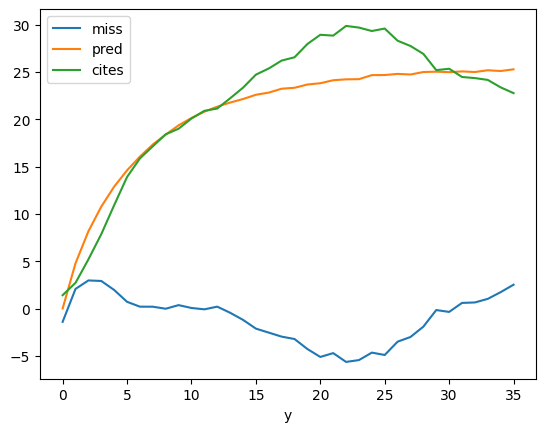

In [81]:
_sdf = (
    pd.Series((pred - t_wcites).detach().cpu().numpy(), name="miss")
    .to_frame()
    .assign(
        y=out_since.detach().cpu().numpy(),
        pred=pred.detach().cpu().numpy(),
        cites=wcits[stinds],
    )
    .astype(float)
)
_sdf.groupby("y").agg("mean").loc[:35, :].plot()

<Axes: xlabel='y'>

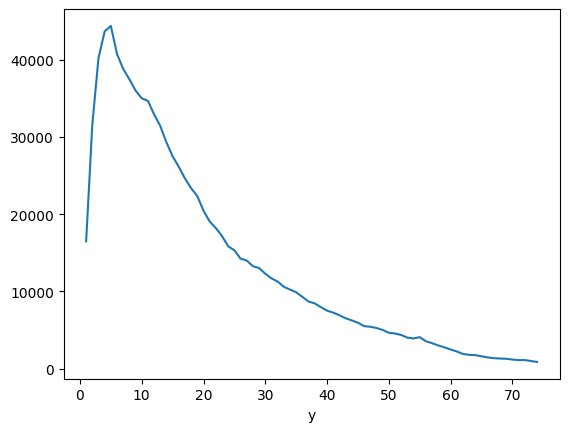

In [86]:
_sdf.groupby("y").count()["pred"].loc[1:,].plot()

<Axes: xlabel='y'>

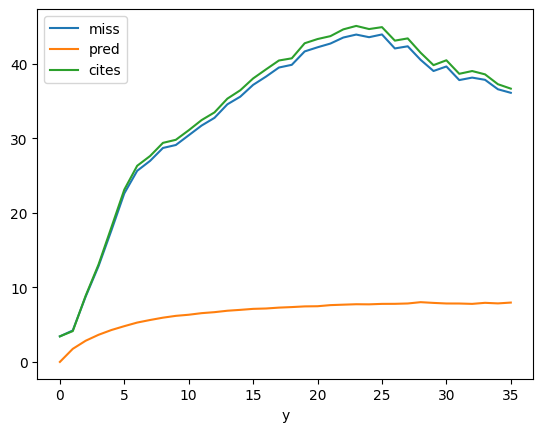

In [94]:
_sdf.groupby("y").agg("std").loc[:35, :].plot()

In [63]:
alpha

tensor([ 5.9682,  2.3644, -0.9622,  3.3722,  3.9978,  2.5726,  5.3465,  8.3737,
         3.3014,  3.3306,  3.3723,  4.6606,  0.2902,  4.1022,  3.8551,  3.3395,
         2.1493,  6.4760,  0.9962,  0.0853,  1.6343,  6.8743,  4.7521, -0.1786,
        -1.4428,  6.1673,  5.7910,  7.4366,  2.4406,  2.5608,  3.8539,  6.4258,
         3.9261,  3.8212,  2.9382,  3.7812,  5.4184,  2.8624,  5.7540,  4.6585,
         5.1017,  7.2349,  3.2929,  3.7722,  4.5335,  3.2218,  3.7595,  4.8701,
         1.5250,  5.8171,  4.7185,  3.6859,  5.2941,  1.1627,  3.6096,  2.3548,
        12.2051,  3.0588,  4.6058,  3.8695,  3.9536,  4.1740,  2.9898,  2.6628,
         2.8558,  6.4894,  2.1974,  3.9987,  4.3308,  4.5412,  3.5846,  3.4831,
         3.9878,  1.9795,  2.8328,  1.9336,  6.5859,  9.1072,  4.5835,  4.0801,
         5.0030,  2.6697,  2.9039,  2.8324,  6.4866,  2.7050,  3.3948,  9.0491,
         3.3467,  7.1959,  2.9690,  3.5721,  2.0742,  6.7713,  6.1411,  3.1417,
         1.9909,  2.3608,  5.5575,  3.74

In [41]:
beta

tensor([0.8580, 0.8440, 0.6488, 0.8716, 0.8613, 0.8833, 0.8132, 0.6859, 0.8896,
        0.9196, 0.8824, 0.8957, 0.9504, 0.8391, 0.8626, 0.8637, 0.9073, 0.8638,
        0.8230, 0.9672, 0.9178, 0.9080, 0.8031, 0.7570, 0.8576, 0.8513, 0.6789,
        0.7683, 0.8602, 0.8681, 0.8201, 0.7852, 0.7845, 0.8554, 0.8771, 0.8710,
        0.8253, 0.8584, 0.6997, 0.8613, 0.8928, 0.8325, 0.8703, 0.8766, 0.7227,
        0.8804, 0.8653, 0.8139, 0.8892, 0.8662, 0.7338, 0.8874, 0.8628, 0.8455,
        0.8471, 0.8609, 0.7360, 0.7650, 0.8706, 0.8367, 0.8450, 0.8736, 0.8555,
        0.8461, 0.7860, 0.8391, 0.8712, 0.9047, 0.7737, 0.8845, 0.8572, 0.8826,
        0.8324, 0.8900, 0.8955, 0.7352, 0.8175, 0.7791, 0.7819, 0.8101, 0.8344,
        0.6804, 0.8620, 0.8724, 0.7338, 0.9073, 0.8602, 0.7517, 0.8911, 0.6870,
        0.8843, 0.9122, 0.9283, 0.7414, 0.8285, 0.9050, 0.9030, 0.9305, 0.8350,
        0.8419, 0.9062, 0.7698, 0.8529, 0.8179, 0.7557, 0.9244, 0.8016, 0.8801,
        0.9166, 0.8980, 0.8597, 0.8065, 

In [64]:
loss

tensor(1091.4578, device='cuda:0', grad_fn=<MeanBackward0>)

In [65]:
from ccl_science_data.common import GenReader, get_arr

In [66]:
gr = GenReader("..")

In [90]:
recs = []
j = 0
for i, name in enumerate(gr.get_names(EntC.SUBFIELDS)):
    if i in dropsuf:
        recs.append({"name": name})
        continue
    recs.append({"name": name, "decay": float(beta[j]), "volume": float(alpha[j])})
    j += 1

In [91]:
pdf = pd.DataFrame(recs).sort_values("volume", ascending=False)

In [93]:
pdf.tail(30)

,name,decay,volume
190,Algebra and Number Theory,0.965044,0.516706
245,Chemical Health and Safety,0.905280,0.515280
159,Hardware and Architecture,0.962236,0.476405
215,Museology,0.912072,0.467060
220,Theoretical Computer Science,0.950609,0.414536
241,Microbiology,0.935305,0.394826
212,Forestry,0.953301,0.392264
169,History and Philosophy of Science,0.940446,0.349395
205,Classics,0.862570,0.333689
250,Medical Terminology,0.432985,0.332527


In [211]:
pdf.set_index("name").corr()

,decay,volume
decay,1.000000,-0.790819
volume,-0.790819,1.000000
